**1.Cài thư viện**

In [10]:
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

# Thiết lập giao diện biểu đồ
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'

**2.Load dữ liệu từ pipeline 01 và model từ pipeline 02**
*Notebook này không tự sinh dữ liệu và không tự train lại model. Nó chỉ đọc `dataset_raw.csv` do notebook 01 tạo ra và `sql_predictor.pkl` do notebook 02 lưu lại.*

In [11]:
print("--- BƯỚC 1: TẢI DỮ LIỆU TỪ NOTEBOOK 01 VÀ MODEL TỪ NOTEBOOK 02 ---")

try:
    df = pd.read_csv('dataset_raw.csv')
    print(f"Đã tải dataset_raw.csv với {len(df)} dòng dữ liệu.")
except FileNotFoundError:
    raise FileNotFoundError("Không tìm thấy dataset_raw.csv. Hãy chạy notebook 01_Data_Pipeline.ipynb trước.")

try:
    model = joblib.load('sql_predictor.pkl')
    print("Đã tải sql_predictor.pkl thành công.")
except FileNotFoundError:
    raise FileNotFoundError("Không tìm thấy sql_predictor.pkl. Hãy chạy notebook 02_ML_Model_Training.ipynb trước.")

feature_cols = ['query_length', 'has_where', 'has_group_by', 'has_order_by', 'has_like']
X = df[feature_cols]
y = df['is_slow_query']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Kích thước tập huấn luyện: {X_train.shape}, Tập kiểm tra: {X_test.shape}")

--- BƯỚC 1: TẢI DỮ LIỆU TỪ NOTEBOOK 01 VÀ MODEL TỪ NOTEBOOK 02 ---
Đã tải dataset_raw.csv với 300 dòng dữ liệu.
Đã tải sql_predictor.pkl thành công.
Kích thước tập huấn luyện: (240, 5), Tập kiểm tra: (60, 5)


**3.Chuẩn bị dữ liệu đánh giá**

In [12]:
print("\n--- BƯỚC 2: CHUẨN BỊ ĐẶC TRƯNG ĐÁNH GIÁ ---")

print("Các cột đặc trưng dùng cho model:")
print(list(X.columns))
print("\nMẫu dữ liệu:")
display(df.head())


--- BƯỚC 2: CHUẨN BỊ ĐẶC TRƯNG ĐÁNH GIÁ ---
Các cột đặc trưng dùng cho model:
['query_length', 'has_where', 'has_group_by', 'has_order_by', 'has_like']

Mẫu dữ liệu:


,query_string,query_length,has_where,has_group_by,has_order_by,has_like,row_count,execution_time_ms,is_slow_query
0,SELECT customer_name FROM customer_transaction...,83,1,0,0,1,2132,29.573441,1
1,"SELECT status, COUNT(*) FROM customer_transact...",67,0,1,0,0,4,42.774677,1
2,SELECT customer_name FROM customer_transaction...,83,1,0,0,1,2132,25.771141,1
3,SELECT customer_name FROM customer_transaction...,83,1,0,0,1,2132,26.340008,1
4,SELECT * FROM customer_transactions WHERE age ...,91,1,0,1,0,23825,158.545256,1


**4.Đánh giá mô hình**


--- BƯỚC 3: ĐÁNH GIÁ MODEL TỪ NOTEBOOK 02 ---

--- BÁO CÁO ĐÁNH GIÁ XGBOOST ---
              precision    recall  f1-score   support

           0       0.23      1.00      0.38         6
           1       1.00      0.63      0.77        54

    accuracy                           0.67        60
   macro avg       0.62      0.81      0.57        60
weighted avg       0.92      0.67      0.73        60



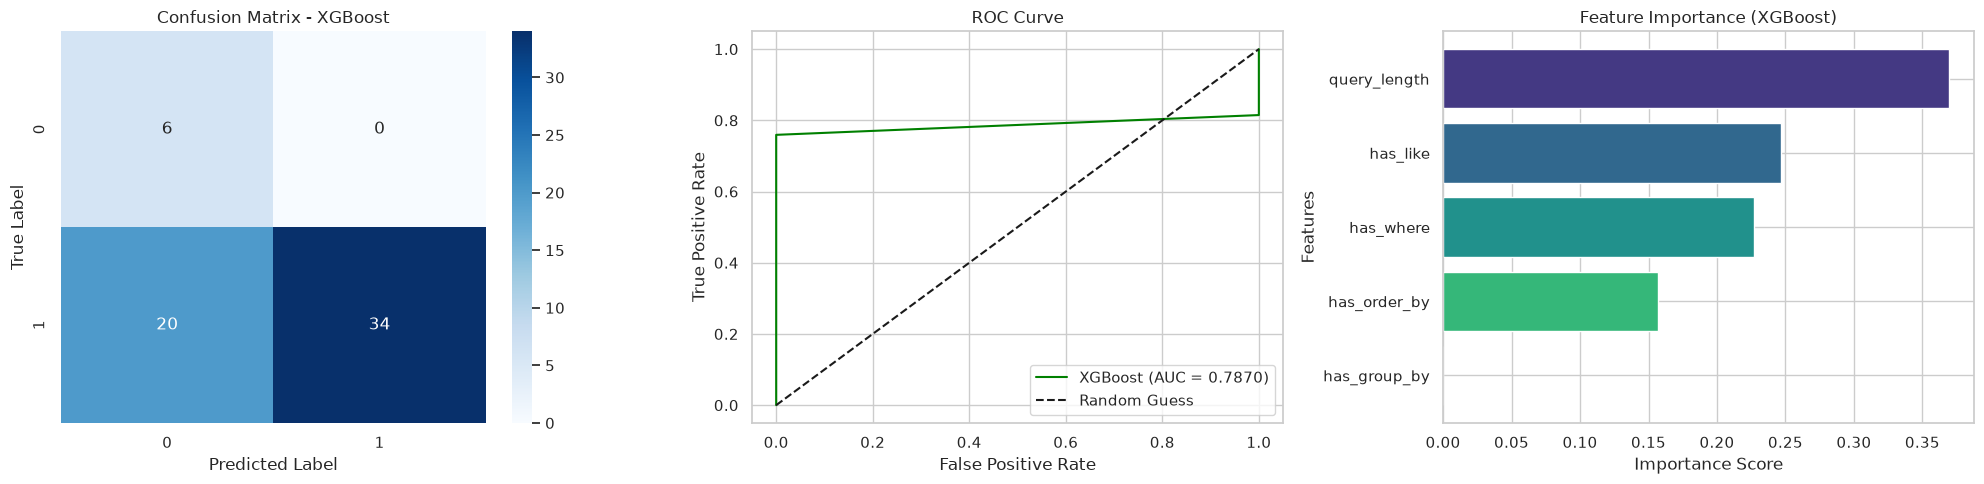

Accuracy: 0.6667
AUC: 0.7870


In [16]:
print("\n--- BƯỚC 3: ĐÁNH GIÁ MODEL TỪ NOTEBOOK 02 ---")

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("\n--- BÁO CÁO ĐÁNH GIÁ XGBOOST ---")
print(classification_report(y_test, y_pred))

accuracy = (y_pred == y_test).mean()
auc_score = roc_auc_score(y_test, y_prob)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion Matrix - XGBoost')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, label=f'XGBoost (AUC = {auc_score:.4f})', color='green')
axes[1].plot([0, 1], [0, 1], 'k--', label='Random Guess')
axes[1].set_title('ROC Curve')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(loc='lower right')

feature_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

axes[2].barh(feature_imp['Feature'], feature_imp['Importance'], color=sns.color_palette('viridis', len(feature_imp)))
axes[2].invert_yaxis()
axes[2].set_title('Feature Importance (XGBoost)')
axes[2].set_xlabel('Importance Score')
axes[2].set_ylabel('Features')

plt.tight_layout()
plt.show()

print(f"Accuracy: {accuracy:.4f}")
print(f"AUC: {auc_score:.4f}")